In [1]:
# collect total energies from OUTCARs and compute corrected per-atom values
import os
import numpy as np
from ase import io
from ase.atoms import Atoms
from ase.eos import EquationOfState
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit


# reference energies per atom (eV)
atomic_refs = {"Li": -0.72092046, "Ni": -6.83535515, "O": -2.95452644}
#atomic_refs = {"Li": 0, "Ni": 0, "O": 0}


def collect_outcar_data(base_dir, subpattern="s*"):
    """Return a DataFrame with energies and volumes for each OUTCAR.
    …
    """
    entries = []
    pattern = os.path.join(base_dir, subpattern, "OUTCAR")
    for filepath in glob.glob(pattern):
        atoms = io.read(filepath, format="vasp-out")
        e_tot = atoms.get_potential_energy()
        nat = len(atoms)
        vol = atoms.get_volume()
        symbols = atoms.get_chemical_symbols()
        counts = {}
        for s in symbols:
            counts[s] = counts.get(s, 0) + 1
        ref_total = sum(counts.get(el, 0) * atomic_refs.get(el, 0)
                        for el in counts)
        entries.append({
            "path": filepath,
            "energy": e_tot,
            "energy_per_atom": e_tot / nat,
            "corr_energy_per_atom": (e_tot - ref_total) / nat,
            "vol_per_atom": vol / nat,
            **counts,
        })

    return pd.DataFrame(entries)

In [2]:
# collect total energies from lammps pressure runs out of csv data
def collect_lammps_csv(base_dir):
    """
    Liest alle pv_up/pv_down CSVs in einem LAMMPS-Ordner ein und vereinheitlicht die Spaltennamen.
    """
    entries = []
    for csv_file in ["pv_down.csv", "pv_up.csv"]:
        full_path = os.path.join(base_dir, csv_file)
        if not os.path.exists(full_path):
            continue
        df = pd.read_csv(full_path)
        # Spalten umbenennen für Einheitlichkeit
        df = df.rename(columns={
            "V_per_atom_A3": "vol_per_atom",
            "E_per_atom_eV": "energy_per_atom"
        })
        df["source_file"] = csv_file
        entries.append(df)
    if entries:
        return pd.concat(entries, ignore_index=True)
    else:
        return pd.DataFrame()

In [3]:
EV_A3_TO_GPA = 160.21766208  # 1 eV/Å^3 = 160.21766208 GPa

# --------------------------------------------------
# Birch–Murnaghan E(V)
# --------------------------------------------------
def birch_murnaghan_energy(V, E0, V0, K0, K0p):
    eta = (V0 / V) ** (2 / 3)
    return E0 + (9 * V0 * K0 / 16) * ((eta - 1) ** 3 * K0p + (eta - 1) ** 2 * (6 - 4 * eta))

# --------------------------------------------------
# Fit helper
# --------------------------------------------------
def fit_bm_from_df(df_in, label="data"):
    """
    Nimmt df_in mit Spalten ['V_per_atom_A3', 'E_per_atom_eV'] und führt Birch–Murnaghan-Fit durch.
    Gibt ein dict mit Fit-Parametern, Fehlern, R², RMSE zurück.
    """
    d = df_in[["V_per_atom_A3", "E_per_atom_eV"]].dropna()
    V, E = d["V_per_atom_A3"].to_numpy(), d["E_per_atom_eV"].to_numpy()
    o = np.argsort(V)
    V, E = V[o], E[o]

    # Startwerte: E0, V0, K0(eV/A^3), K0'
    p0 = [E.min(), V[np.argmin(E)], 180.0, 4.0]

    # Fit
    params, cov = curve_fit(birch_murnaghan_energy, V, E, p0=p0, maxfev=10000)
    std = np.sqrt(np.diag(cov))
    res = E - birch_murnaghan_energy(V, *params)
    ss_tot = np.sum((E - E.mean())**2)
    ss_res = np.sum(res**2)
    
    return dict(
        label=label,
        V=V,
        E=E,
        params=params,
        std=std,
        cov=cov,
        R2=(1 - ss_res / ss_tot) if ss_tot else np.nan,
        RMSE=np.sqrt(np.mean(res**2))
    )

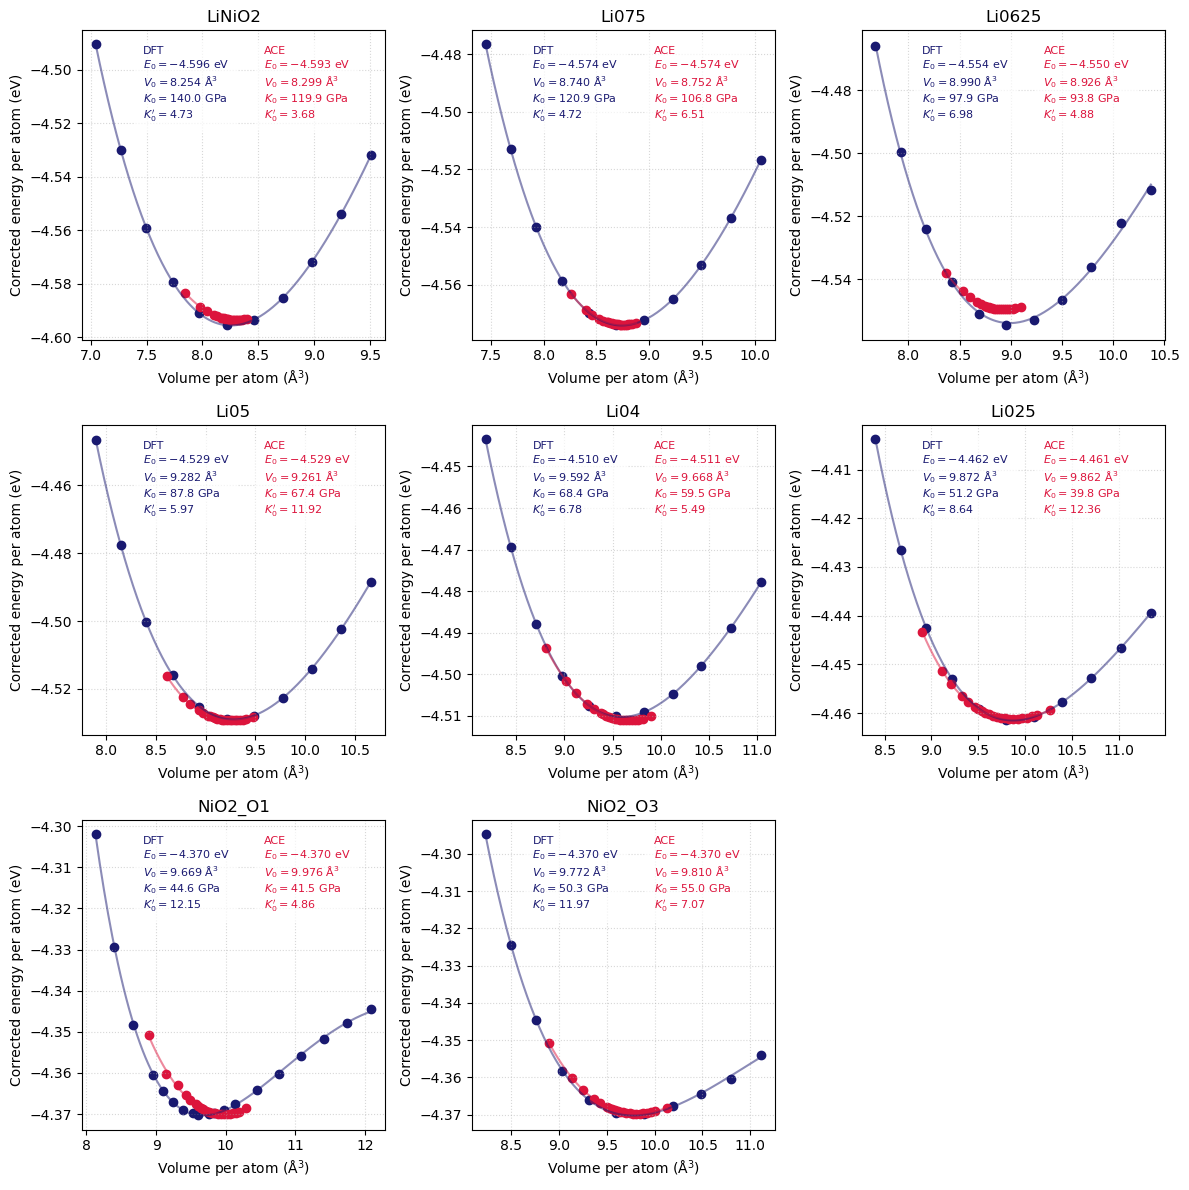

In [8]:
# loop over every subfolder, compute energies, and plot in a grid
#base_dirs = [d for d in os.listdir('.') if os.path.isdir(d)]
#base_dirs = glob.glob("relax_shape/*/*")

base_dirs = [os.path.dirname(f) for f in glob.glob("../../../dft_e-v_curves/relax_shape/*/")]
base_dirs = sorted(set(base_dirs))

# LAMMPS directories
lmp_dirs = [d for d in glob.glob("*/") if os.path.isdir(d)]
lmp_dirs = sorted(lmp_dirs)
lmp_map = {os.path.basename(d.rstrip('/')): d for d in lmp_dirs}

# gather dataframes and compute Li/Ni ratios
panels = []
for d in base_dirs:
    name = os.path.basename(d)

    df_d = collect_outcar_data(d, subpattern="s*")

    # LAMMPS dataframe (falls vorhanden)
    df_lmp = collect_lammps_csv(lmp_map[name]) if name in lmp_map else pd.DataFrame()

    if df_d.empty:
        continue
    # assume composition is constant within each directory
    nLi = df_d.get('Li', pd.Series([0])).iloc[0]
    nNi = df_d.get('Ni', pd.Series([0])).iloc[0]
    ratio = nLi / nNi if nNi != 0 else np.inf
    panels.append((d, ratio, df_d, df_lmp))

# sort by decreasing Li/Ni fraction
panels.sort(key=lambda x: x[1], reverse=True)

# determine grid shape (use square-ish layout)
num = len(panels)
cols = int(np.ceil(np.sqrt(num)))
rows = int(np.ceil(num / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for ax, item in zip(axes.ravel(), panels):
    d, ratio, df_d, df_lmp = item
    ax.scatter(df_d['vol_per_atom'], df_d['corr_energy_per_atom'], c='midnightblue', label='DFT')
    ax.scatter(df_lmp['vol_per_atom'], df_lmp['energy_per_atom'], c='crimson', label='LAMMPS')
    ax.set_title(os.path.basename(d))    
    ax.set_xlabel(r'Volume per atom ($\mathrm{\AA}^3$)')
    ax.set_ylabel(r'Corrected energy per atom (eV)')
    ax.grid(ls=":", alpha=0.5)

    # BM fit to corrected per-atom energies for DFT
    vols = df_d['vol_per_atom'].values
    engs = df_d['corr_energy_per_atom'].values
    
    if len(vols) >= 3:
        # Startwerte
        p0 = [engs.min(), vols[np.argmin(engs)], 0.5, 4.0]

        params, cov = curve_fit(
            birch_murnaghan_energy,
            vols,
            engs,
            p0=p0,
            maxfev=20000
)

        E0, V0, K0, K0p = params
        B_gpa = K0 * EV_A3_TO_GPA

        vfit = np.linspace(vols.min(), vols.max(), 200)
        efit = birch_murnaghan_energy(vfit, E0, V0, K0, K0p)
        ax.plot(vfit, efit, '-', color='midnightblue', alpha=0.5)
        
        text_dft = (
            "DFT\n"
            rf"$E_0={E0:.3f}\ \mathrm{{eV}}$" "\n"
            rf"$V_0={V0:.3f}\ \mathrm{{\AA}}^3$" "\n"
            rf"$K_0={B_gpa:.1f}\ \mathrm{{GPa}}$" "\n"
            rf"$K_0'={K0p:.2f}$"
        )
        
        ax.text(
            0.2, 0.95,
            text_dft,
            transform=ax.transAxes,
            va='top',
            fontsize=8,
            color='midnightblue',
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none',
                boxstyle='round,pad=0.75'
            )
        )
    
    
    # BM fit to corrected per-atom energies for Lammps

    vols_l = df_lmp['vol_per_atom'].values
    engs_l = df_lmp['energy_per_atom'].values

    if len(vols_l) >= 3:
        p0_l = [engs_l.min(), vols_l[np.argmin(engs_l)], 0.5, 4.0]

        # sort data
        order = np.argsort(vols_l)
        vols_l = vols_l[order]
        engs_l = engs_l[order]

        try:

            params_l, _ = curve_fit(
                birch_murnaghan_energy,
                vols_l,
                engs_l,
                p0=p0_l,
                maxfev=20000
            )

            E0_l, V0_l, K0_l, K0p_l = params_l
            B_gpa_l = K0_l * EV_A3_TO_GPA

            vfit_l = np.linspace(vols_l.min(), vols_l.max(), 200)
            efit_l = birch_murnaghan_energy(vfit_l, E0_l, V0_l, K0_l, K0p_l)

            ax.plot(vfit_l, efit_l, '-', color='crimson', alpha=0.5)

        except RuntimeError:
            print(f"LAMMPS fit failed for {d}")



        text_lmp = (
            "ACE\n"
            rf"$E_0={E0_l:.3f}\ \mathrm{{eV}}$" "\n"
            rf"$V_0={V0_l:.3f}\ \mathrm{{\AA}}^3$" "\n"
            rf"$K_0={B_gpa_l:.1f}\ \mathrm{{GPa}}$" "\n"
            rf"$K_0'={K0p_l:.2f}$"
        )

        ax.text(
            0.6, 0.95,
            text_lmp,
            transform=ax.transAxes,
            va='top',
            fontsize=8,
            color='crimson',
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none',
                boxstyle='round,pad=0.75'
            )
        )


# hide any unused subplots
for ax in axes.ravel()[len(panels):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()